In [2]:
from sklearn.utils import resample

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# Step 2: Load the dataset
df = pd.read_csv("Dataset/diabetes_prediction_dataset.csv")
df.shape

(100000, 9)

In [4]:
df
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
df = df[df['gender'] != 'other']
# Map Male = 0, Female = 1
gender_map = {'male': 0, 'female': 1}
df['gender'] = df['gender'].map(gender_map)
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,never,25.19,6.6,140,0
1,1,54.0,0,0,No Info,27.32,6.6,80,0
2,0,28.0,0,0,never,27.32,5.7,158,0
3,1,36.0,0,0,current,23.45,5.0,155,0
4,0,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,1,80.0,0,0,No Info,27.32,6.2,90,0
99996,1,2.0,0,0,No Info,17.37,6.5,100,0
99997,0,66.0,0,0,former,27.83,5.7,155,0
99998,1,24.0,0,0,never,35.42,4.0,100,0


In [5]:
print(df['smoking_history'].unique())


['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [6]:
df['smoking_history'] = df['smoking_history'].astype(str).str.strip().str.lower()


In [7]:
# Step 2: Map into yes / no / former
df['smoking_history'] = df['smoking_history'].replace({
    'current': 'yes',
    'former': 'former',
    'ever': 'former',
    'not current': 'former',
    'never': 'no',
    'no info': 'no'   # or 'unknown' if you want to track that separately
})

In [8]:
smoking_map = {'no': 0, 'former': 1, 'yes': 2}
df['smoking_history'] = df['smoking_history'].map(smoking_map)

df



,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,0,25.19,6.6,140,0
1,1,54.0,0,0,0,27.32,6.6,80,0
2,0,28.0,0,0,0,27.32,5.7,158,0
3,1,36.0,0,0,2,23.45,5.0,155,0
4,0,76.0,1,1,2,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,1,80.0,0,0,0,27.32,6.2,90,0
99996,1,2.0,0,0,0,17.37,6.5,100,0
99997,0,66.0,0,0,1,27.83,5.7,155,0
99998,1,24.0,0,0,0,35.42,4.0,100,0


In [9]:
# Step 4: Split into features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [10]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:

# 2️⃣ Combine train features and labels for resampling
train_data = pd.concat([X_train, y_train], axis=1)

# Separate majority and minority classes
majority = train_data[train_data.diabetes == 0]
minority = train_data[train_data.diabetes == 1]

# 3️⃣ Undersample majority class (down to minority size)
majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

# 4️⃣ Combine undersampled majority with minority
train_balanced = pd.concat([majority_downsampled, minority])

# Shuffle
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Final train/test splits
X_train = train_balanced.drop("diabetes", axis=1)
y_train = train_balanced["diabetes"]

# X_test, y_test remain untouched (still imbalanced, realistic!)
print("Balanced train shape:", X_train.shape, y_train.value_counts().to_dict())
print("Test shape(Imbalanced):", X_test.shape, y_test.value_counts().to_dict())


Balanced train shape: (13600, 8) {1: 6800, 0: 6800}
Test shape(Imbalanced): (19997, 8) {0: 18297, 1: 1700}


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def compare_classifiers(X_train, y_train, X_test, y_test):
    models = {
        "Random Forest": RandomForestClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "MLP (Neural Net)": MLPClassifier(max_iter=1000),
        "SVM": SVC(),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }
    
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name}: {acc:.4f}")
    
    print("\nBest model:", max(results, key=results.get), "with accuracy", results[max(results, key=results.get)])

# Example usage:
compare_classifiers(X_train, y_train, X_test, y_test)


Random Forest: 0.9005
Logistic Regression: 0.8889
MLP (Neural Net): 0.7510
SVM: 0.8237
XGBoost: 0.9001

Best model: Random Forest with accuracy 0.9005350802620393


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:12:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

xgb_clf = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)

random_search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist,
    n_iter=20, scoring='accuracy', cv=5, verbose=1,
    random_state=42, n_jobs=2
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV accuracy: 0.9109558823529411


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:12:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_xgb = xgb.XGBClassifier(
    subsample=1.0,
    n_estimators=200,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=0.8,
    eval_metric='logloss'  # keep to avoid deprecated warning
  
)

# Train on full training data
best_xgb.fit(X_train, y_train)

# Predict on test data
y_pred = best_xgb.predict(X_test)

# Evaluate
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9019852977946692

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.90      0.94     18297
           1       0.46      0.92      0.61      1700

    accuracy                           0.90     19997
   macro avg       0.73      0.91      0.78     19997
weighted avg       0.95      0.90      0.92     19997


Confusion Matrix:
 [[16473  1824]
 [  136  1564]]


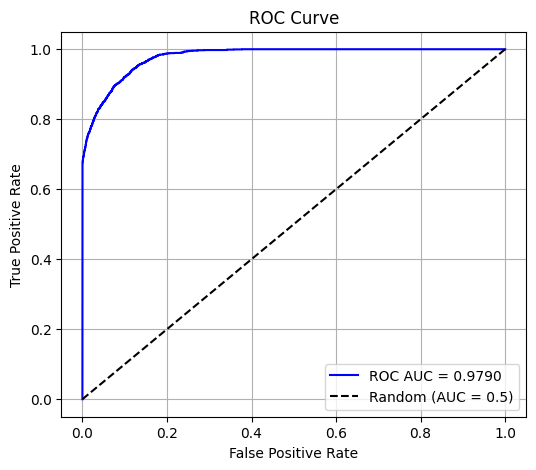

ROC AUC Score: 0.9790


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve

# 1️⃣ Get probabilities for the positive class (class 1)
# best_xgb.predict_proba(X_test) outputs a 2D array where each row corresponds to a test sample. 
# Each row contains two values: the probability that the sample belongs to class 0 and the probability it belongs to class 1.
# [:, 1] selects the probability of the positive class (in your case, class "1" = diabetes).
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# 2️⃣ ROC AUC
roc_auc = roc_auc_score(y_test, y_probs)
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()



# 4️⃣ Print both scores
print(f"ROC AUC Score: {roc_auc:.4f}")


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


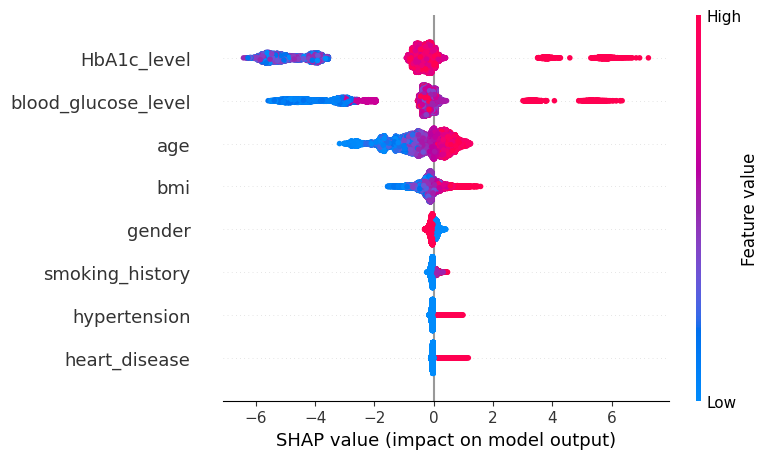

In [16]:
import shap
import matplotlib.pyplot as plt

# Initialize the SHAP TreeExplainer for the best_xgb model
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# 1) Summary Plot: feature importance and effect direction
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)




